In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv('housing.csv')
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [48]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [50]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [51]:
df.shape

(20640, 10)

In [52]:
df['ocean_proximity'].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [53]:
#Dropping data since it is less than 1%
cleaned_df = df.dropna()

In [54]:
cleaned_df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [55]:
cleaned_df.shape

(20433, 10)

In [56]:
df['ocean_proximity'].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [57]:
#Created 5 new columns to represent ocean_proximity since we cant perform ml in textual format
cleaned_df['is_near_bay'] = np.where(cleaned_df['ocean_proximity'].str.contains('NEAR BAY'), 1, 0)
cleaned_df['is_<1h_ocean'] = np.where(cleaned_df['ocean_proximity'].str.contains('<1H OCEAN'), 1, 0)
cleaned_df['is_inland'] = np.where(cleaned_df['ocean_proximity'].str.contains('INLAND'), 1, 0)
cleaned_df['is_near_ocean'] = np.where(cleaned_df['ocean_proximity'].str.contains('NEAR OCEAN'), 1, 0)
cleaned_df['is_island'] = np.where(cleaned_df['ocean_proximity'].str.contains('ISLAND'), 1, 0)

In [58]:
#Dropping the initial ocean proximity since we have created 5 new columnns for each value
cleaned_df = cleaned_df.drop(columns=['ocean_proximity'])

In [59]:
#Droppped median_house_value from x to seperate it into x train and test
X = cleaned_df.drop(columns=['median_house_value'])
y = cleaned_df[['median_house_value']]

In [60]:
#Seperated the x to train and test in 80% and 20% with random state 42 to shuffle the data and 42 for reproducibility
X_train = X.sample(frac=0.8, random_state=42)
X_test = X.drop(X_train.index)

y_train = y.sample(frac=0.8, random_state=42)
y_test = y.drop(X_train.index)

original_y_test = y_test
original_y_train = y_train
y_mean = y_train.mean()
y_std = y_train.std()

In [61]:
#Performed Standardaization scaling
columns_to_scale = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
scalled_X_train = (X_train[columns_to_scale] - X_train[columns_to_scale].mean()) / X_train[columns_to_scale].std()
scalled_X_test = (X_test[columns_to_scale] - X_train[columns_to_scale].mean()) / X_train[columns_to_scale].std()

In [62]:
#Replaced the value of scaled to the original train and test dataset without scaling certain columns -> ocean proximity
X_train[columns_to_scale] = scalled_X_train[columns_to_scale]
X_test[columns_to_scale] = scalled_X_test[columns_to_scale]

In [63]:
#Performed Standardization scaling
scalled_y_train = (y_train - y_train.mean() )/y_train.std()
scalled_y_test = (y_test - y_train.mean() )/y_train.std()
y_train = scalled_y_train
y_test = scalled_y_test

In [64]:
def compute_gradient_descent(X_train, y_train, w, b, alpha, n):
    m = len(X_train)
    cost_history = []
    for i in range(n):
        pred = X_train @ w + b
        error = pred - y_train
        
        w_gradient = (2/m) * (X_train.T @ error)
        b_gradient = (2/m) * (np.sum(error))

        w = w - (w_gradient * alpha)
        b = b - (b_gradient * alpha)

        cost = 1/m * np.sum(error ** 2)
        cost_history.append(cost)
    return  w, b,cost_history

In [65]:
w_initial = np.zeros(X_train.shape[1])
b_initial = 0
alpha = 0.1
n = 500
X_train_np = X_train.values
y_train_np = y_train.values.flatten()
w_final, b_final, cost = compute_gradient_descent(X_train_np, y_train_np, w_initial, b_initial, alpha, n)
#print(cost)
print(f"w: {w_final}")
print(f"b: {b_final}")

w: [-0.41758886 -0.42112682  0.12268017 -0.12026644  0.34552564 -0.35815659
  0.17855084  0.64937932  0.06175505  0.08380391 -0.28146989  0.13986157
  0.02284499]
b: 0.026795631328133607


In [66]:
type(y_mean)

pandas.Series

In [67]:
#Performing in test set
X_test_np = X_test.values
test_prediction = X_test_np @ w_final + b_final
y_std = y_std.to_numpy().item()
y_mean = y_mean.to_numpy().item()
# y_std = float(y_std)
# y_mean = float(y_mean)
prediction_dollar = (test_prediction * y_std) + y_mean
actual_dollar = original_y_test.values
error_dollar = actual_dollar - prediction_dollar

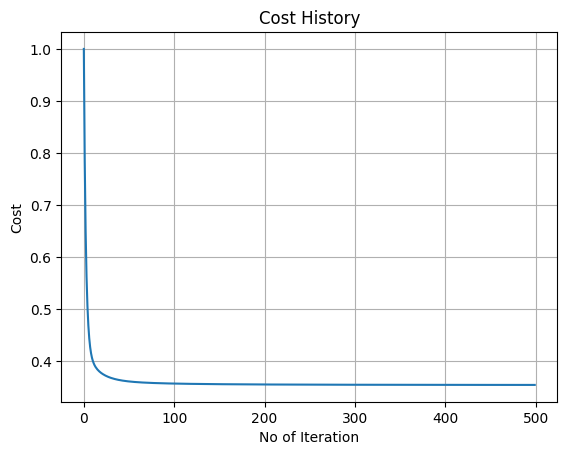

In [69]:
plt.plot(range(n), cost)
plt.xlabel('No of Iteration')
plt.ylabel('Cost')
plt.title('Cost History')
plt.grid()

In [70]:
# Extract scalars
y_std_value = float(y_std.iloc[0]) if hasattr(y_std, 'iloc') else float(y_std)
y_mean_value = float(y_mean.iloc[0]) if hasattr(y_mean, 'iloc') else float(y_mean)

# Convert predictions
prediction_dollar = (test_prediction * y_std_value) + y_mean_value

# Flatten actual values
actual_dollar = original_y_test.values.flatten()

# Calculate errors
error_dollar = actual_dollar - prediction_dollar

# Calculate metrics
mse = np.mean(error_dollar ** 2)
rmse = np.sqrt(mse)
r2 = 1 - (np.sum(error_dollar ** 2) / np.sum((actual_dollar - np.mean(actual_dollar)) ** 2))

print(f"RMSE: ${rmse:,.0f}")
print(f"R²: {r2:.4f}")

RMSE: $68,707
R²: 0.6435


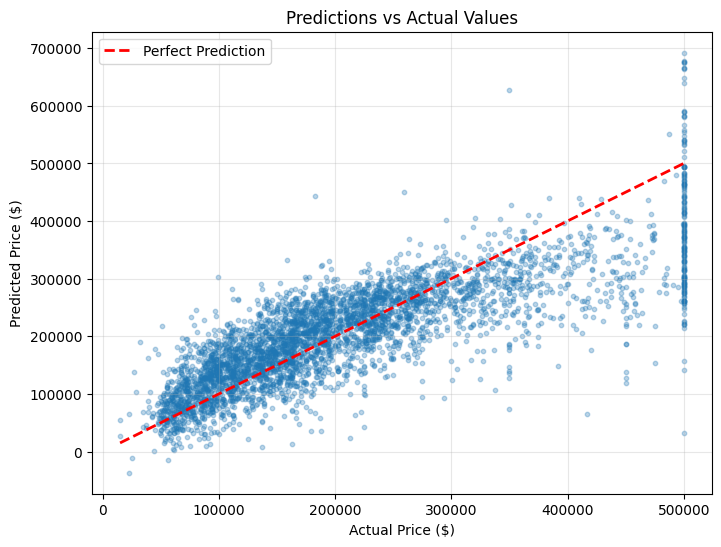

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(actual_dollar, prediction_dollar, alpha=0.3, s=10)
plt.plot([actual_dollar.min(), actual_dollar.max()], 
         [actual_dollar.min(), actual_dollar.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predictions vs Actual Values')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()